In [ ]:
import numpy as np
import quantecon as qe
from scipy.stats import lognorm
import matplotlib.pyplot as plt
from scipy.integrate import quad



ImportError: cannot import name 'rng' from 'numpy' (/home/lucas/yes/envs/quantecon_modeling/lib/python3.11/site-packages/numpy/__init__.py)

The numerical integration based option price is 15.188 with an error of 1.674017724440091e-08


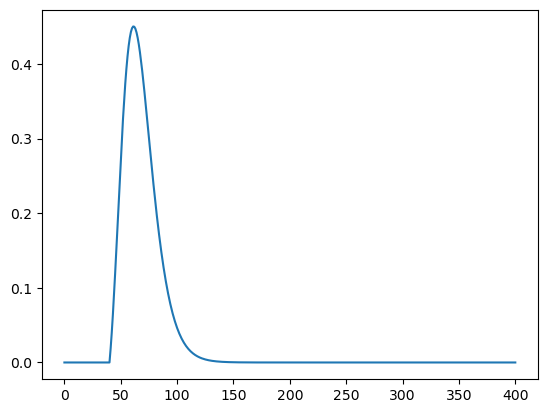

In [14]:
def g(x):
    return (0.99**10) * np.maximum(x - 40, 0) * lognorm.pdf(x,0.25,scale=np.exp(4))

x = np.linspace(0,400,400, dtype=int)
y = g(x)

fig, ax = plt.subplots()
ax.plot(x,y)

P, error= quad(g,0,400)
print(f"The numerical integration based option price is {P:.3f} with an error of {error}")

In [15]:
M = 10_000_000
S = np.exp(4 + 0.25 * np.random.default_rng().standard_normal(M))
draws = np.maximum(S - 40,0)
P2 = (0.99 ** 10) * np.mean(draws)
print(P2)


15.190616795606259


In [18]:
def bisect(f,a,b):

    if a > b:
        return -1
    
    middle = (a + b) / 2

    if f(middle) == 0:
        return middle

    if f(middle) > 0:
        return bisect(f,a,middle)
    else:
        return bisect(f,middle,b)

f = lambda x: np.sin(4 * (x - 1/4)) + x + x**20 - 1
print(bisect(f,0,1))

0.40829350427936706
